In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import wrds

print("Python executable:", sys.executable)
print("Pandas version:", pd.__version__)

Python executable: /opt/anaconda3/envs/dissertation/bin/python
Pandas version: 2.2.3


In [2]:
project_root = Path("..")
processed_dir = project_root / "data" / "processed"

print("Files in processed folder:")
for file in processed_dir.glob("*"):
    print(file)

Files in processed folder:
../data/processed/.gitkeep
../data/processed/crsp_daily_2010_2024.parquet


In [3]:
old_panel_path = processed_dir / "crsp_daily_2010_2024.parquet"

old_panel = pd.read_parquet(old_panel_path)

print("Shape:", old_panel.shape)
print("Columns:", old_panel.columns.tolist())
old_panel.head()

Shape: (2235322, 5)
Columns: ['permno', 'date', 'ticker', 'ret', 'mktcap']


,permno,date,ticker,ret,mktcap
0,10078,2010-01-04,JAVA,0.001067,7071957.2
1,10078,2010-01-05,JAVA,0.001066,7079496.6
2,10078,2010-01-06,JAVA,-0.003195,7056878.4
3,10078,2010-01-07,JAVA,0.004274,7087036.0
4,10078,2010-01-08,JAVA,-0.002128,7071957.2


In [4]:
old_panel["date"] = pd.to_datetime(old_panel["date"])

print("Number of rows:", len(old_panel))
print("Number of securities:", old_panel["permno"].nunique())
print("Minimum date:", old_panel["date"].min())
print("Maximum date:", old_panel["date"].max())

print("\nDuplicate PERMNO-date rows:")
print(old_panel.duplicated(subset=["permno", "date"]).sum())

print("\nMissing values:")
print(old_panel.isna().sum())

print("\nReturn summary:")
print(old_panel["ret"].describe())

print("\nReturns below -100%:")
print((old_panel["ret"] < -1).sum())

print("\nMarket-cap values below zero:")
print((old_panel["mktcap"] < 0).sum())

Number of rows: 2235322
Number of securities: 744
Minimum date: 2010-01-04 00:00:00
Maximum date: 2024-12-31 00:00:00

Duplicate PERMNO-date rows:
0

Missing values:
permno       0
date         0
ticker       0
ret       1105
mktcap     999
dtype: int64

Return summary:
count    2234217.0
mean      0.000659
std       0.022347
min      -0.904843
25%      -0.008654
50%        0.00067
75%       0.009986
max       2.789474
Name: ret, dtype: Float64

Returns below -100%:
0

Market-cap values below zero:
0


In [5]:
stocks_per_day = old_panel.groupby("date")["permno"].nunique()

print(stocks_per_day.describe())

count    3774.000000
mean      592.295178
std        31.991614
min       544.000000
25%       561.000000
50%       590.000000
75%       627.000000
max       634.000000
Name: permno, dtype: float64


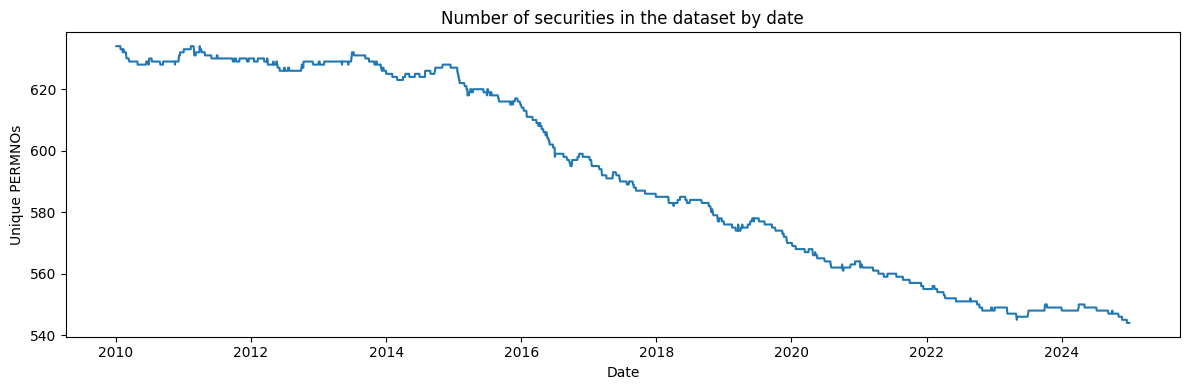

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(stocks_per_day.index, stocks_per_day.values)
plt.title("Number of securities in the dataset by date")
plt.xlabel("Date")
plt.ylabel("Unique PERMNOs")
plt.tight_layout()
plt.show()

In [7]:
db = wrds.Connection()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [8]:
required_tables = [
    "dsf",
    "dsenames",
    "dsedelist",
    "dsp500list"
]

available_tables = db.list_tables(library="crsp")

for table in required_tables:
    print(table, "available:", table in available_tables)

dsf available: True
dsenames available: True
dsedelist available: True
dsp500list available: True


In [9]:
membership = db.raw_sql(
    """
    SELECT
        permno,
        start AS member_start,
        ending AS member_end
    FROM crsp.dsp500list
    WHERE ending >= '2010-01-01'
      AND start <= '2024-12-31'
    ORDER BY permno, start
    """,
    date_cols=["member_start", "member_end"]
)

print("Membership rows:", len(membership))
print("Unique PERMNOs:", membership["permno"].nunique())

membership.head(10)

Membership rows: 828
Unique PERMNOs: 817


,permno,member_start,member_end
0,10078,1992-08-20,2010-01-28
1,10104,1989-08-03,2024-12-31
2,10107,1994-06-07,2024-12-31
3,10137,2000-12-11,2011-02-25
4,10138,1999-10-13,2024-12-31
5,10145,1925-12-31,2024-12-31
6,10147,1996-03-28,2016-09-07
7,10225,1925-12-31,2014-04-30
8,10299,2000-04-03,2017-03-10
9,10324,2001-12-14,2011-04-01


In [10]:
membership_check = old_panel[["permno", "date"]].merge(
    membership,
    on="permno",
    how="left"
)

membership_check["inside_membership"] = (
    membership_check["date"].ge(membership_check["member_start"])
    & membership_check["date"].le(membership_check["member_end"])
)

In [11]:
valid_keys = (
    membership_check.loc[
        membership_check["inside_membership"],
        ["permno", "date"]
    ]
    .drop_duplicates()
)

valid_keys["valid_member"] = True

In [12]:
old_panel_checked = old_panel.merge(
    valid_keys,
    on=["permno", "date"],
    how="left"
)

old_panel_checked["valid_member"] = (
    old_panel_checked["valid_member"]
    .fillna(False)
    .astype(bool)
)

invalid_membership_rows = old_panel_checked[
    ~old_panel_checked["valid_member"]
].copy()

print("Total old rows:", len(old_panel_checked))
print("Rows inside a valid membership period:",
      old_panel_checked["valid_member"].sum())
print("Rows outside membership periods:",
      len(invalid_membership_rows))

Total old rows: 2235322
Rows inside a valid membership period: 1711519
Rows outside membership periods: 523803


/var/folders/_c/yg012l_n2yv7l61p686nm5s80000gn/T/ipykernel_82173/4282023310.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [ ]:
invalid_membership_rows[
    ["permno", "ticker", "date", "ret"]
].head(20)

In [ ]:
invalid_membership_summary = pd.DataFrame([{
    "n_invalid_rows": len(invalid_membership_rows),
    "n_unique_permnos": invalid_membership_rows["permno"].nunique(),
    "date_range_start": invalid_membership_rows["date"].min(),
    "date_range_end": invalid_membership_rows["date"].max(),
}])

# Note: intentionally NOT saving the raw rows (permno/date/ticker/ret/mktcap) —
# that would be real CRSP return data in a committed report table, which WRDS
# licensing terms don't allow. This summary preserves the audit's purpose
# (documenting data quality) without redistributing licensed data.
invalid_membership_summary.to_csv(
    project_root / "reports" / "tables" /
    "invalid_sp500_membership_rows_summary.csv",
    index=False
)

print("Invalid membership row summary saved (aggregate only, no raw CRSP data).")


In [16]:
delisting_audit = db.raw_sql(
    """
    SELECT
        a.permno,
        a.date,
        a.ret AS ret_raw,
        d.dlret
    FROM crsp.dsf AS a
    INNER JOIN crsp.dsedelist AS d
        ON a.permno = d.permno
       AND a.date = d.dlstdt
    WHERE a.date BETWEEN '2010-01-01' AND '2024-12-31'
      AND d.dlret IS NOT NULL
    ORDER BY a.date
    """,
    date_cols=["date"]
)

print("Matching RET and DLRET rows:", len(delisting_audit))
delisting_audit.head(20)

Matching RET and DLRET rows: 7216


,permno,date,ret_raw,dlret
0,10371,2010-01-05,-0.047619,0.014969
1,88432,2010-01-05,-0.521333,-0.233983
2,90025,2010-01-05,0.297017,-0.3
3,78432,2010-01-06,-0.013873,0.008206
4,84730,2010-01-06,-0.198701,-0.189627
5,87564,2010-01-07,-0.142857,-0.166667
6,85756,2010-01-08,0.173333,0.318182
7,10563,2010-01-11,-0.690789,-0.432624
8,11162,2010-01-13,0.034483,0.261905
9,87317,2010-01-13,0.008,0.0


In [17]:
delisting_audit["ret_raw"] = pd.to_numeric(
    delisting_audit["ret_raw"],
    errors="coerce"
)

delisting_audit["dlret"] = pd.to_numeric(
    delisting_audit["dlret"],
    errors="coerce"
)

In [18]:
both_missing = (
    delisting_audit["ret_raw"].isna()
    & delisting_audit["dlret"].isna()
)

delisting_audit["ret_combined"] = (
    (1 + delisting_audit["ret_raw"].fillna(0))
    * (1 + delisting_audit["dlret"].fillna(0))
    - 1
)

delisting_audit.loc[both_missing, "ret_combined"] = np.nan

In [19]:
delisting_audit["ret_if_replaced"] = delisting_audit["dlret"]

delisting_audit["difference"] = (
    delisting_audit["ret_combined"]
    - delisting_audit["ret_if_replaced"]
)

delisting_audit[
    [
        "permno",
        "date",
        "ret_raw",
        "dlret",
        "ret_if_replaced",
        "ret_combined",
        "difference"
    ]
].head(20)

,permno,date,ret_raw,dlret,ret_if_replaced,ret_combined,difference
0,10371,2010-01-05,-0.047619,0.014969,0.014969,-0.033363,-0.048332
1,88432,2010-01-05,-0.521333,-0.233983,-0.233983,-0.633333,-0.39935
2,90025,2010-01-05,0.297017,-0.3,-0.3,-0.092088,0.207912
3,78432,2010-01-06,-0.013873,0.008206,0.008206,-0.005781,-0.013987
4,84730,2010-01-06,-0.198701,-0.189627,-0.189627,-0.350649,-0.161022
5,87564,2010-01-07,-0.142857,-0.166667,-0.166667,-0.285714,-0.119047
6,85756,2010-01-08,0.173333,0.318182,0.318182,0.546666,0.228484
7,10563,2010-01-11,-0.690789,-0.432624,-0.432624,-0.824561,-0.391937
8,11162,2010-01-13,0.034483,0.261905,0.261905,0.305419,0.043514
9,87317,2010-01-13,0.008,0.0,0.0,0.008,0.008


In [20]:
corrected_panel = db.raw_sql(
    """
    SELECT DISTINCT
        a.permno,
        a.date,
        n.ticker,

        a.ret AS ret_raw,
        d.dlret,

        CASE
            WHEN a.ret IS NULL AND d.dlret IS NULL
                THEN NULL
            ELSE
                (1 + COALESCE(a.ret, 0))
                * (1 + COALESCE(d.dlret, 0))
                - 1
        END AS ret,

        ABS(a.prc) * a.shrout AS mktcap,

        s.start AS member_start,
        s.ending AS member_end

    FROM crsp.dsf AS a

    INNER JOIN crsp.dsp500list AS s
        ON a.permno = s.permno
       AND a.date BETWEEN s.start AND s.ending

    INNER JOIN crsp.dsenames AS n
        ON a.permno = n.permno
       AND a.date BETWEEN n.namedt AND n.nameendt

    LEFT JOIN crsp.dsedelist AS d
        ON a.permno = d.permno
       AND a.date = d.dlstdt

    WHERE a.date BETWEEN '2010-01-01' AND '2024-12-31'
      AND n.shrcd IN (10, 11)

    ORDER BY a.permno, a.date
    """,
    date_cols=["date", "member_start", "member_end"]
)

In [21]:
date_columns = [
    "date",
    "member_start",
    "member_end"
]

for column in date_columns:
    corrected_panel[column] = pd.to_datetime(
        corrected_panel[column]
    )

numeric_columns = [
    "ret_raw",
    "dlret",
    "ret",
    "mktcap"
]

for column in numeric_columns:
    corrected_panel[column] = pd.to_numeric(
        corrected_panel[column],
        errors="coerce"
    )

corrected_panel = corrected_panel.sort_values(
    ["permno", "date"]
).reset_index(drop=True)

print(corrected_panel.dtypes)
corrected_panel.head()

permno                   Int64
date            datetime64[ns]
ticker          string[python]
ret_raw                Float64
dlret                  Float64
ret                    Float64
mktcap                 Float64
member_start    datetime64[ns]
member_end      datetime64[ns]
dtype: object


,permno,date,ticker,ret_raw,dlret,ret,mktcap,member_start,member_end
0,10078,2010-01-04,JAVA,0.001067,<NA>,0.001067,7071957.2,1992-08-20,2010-01-28
1,10078,2010-01-05,JAVA,0.001066,<NA>,0.001066,7079496.6,1992-08-20,2010-01-28
2,10078,2010-01-06,JAVA,-0.003195,<NA>,-0.003195,7056878.4,1992-08-20,2010-01-28
3,10078,2010-01-07,JAVA,0.004274,<NA>,0.004274,7087036.0,1992-08-20,2010-01-28
4,10078,2010-01-08,JAVA,-0.002128,<NA>,-0.002128,7071957.2,1992-08-20,2010-01-28


In [22]:
corrected_panel["valid_membership"] = (
    corrected_panel["date"].ge(corrected_panel["member_start"])
    & corrected_panel["date"].le(corrected_panel["member_end"])
)

print(
    corrected_panel["valid_membership"]
    .value_counts(dropna=False)
)

valid_membership
True    1711517
Name: count, dtype: int64


In [23]:
assert corrected_panel["valid_membership"].all(), (
    "Some rows are outside their S&P 500 membership periods."
)

In [24]:
duplicate_count = corrected_panel.duplicated(
    subset=["permno", "date"]
).sum()

print("Duplicate PERMNO-date rows:", duplicate_count)

Duplicate PERMNO-date rows: 0


In [25]:
duplicate_rows = corrected_panel[
    corrected_panel.duplicated(
        subset=["permno", "date"],
        keep=False
    )
].sort_values(["permno", "date"])

duplicate_rows.head(20)

,permno,date,ticker,ret_raw,dlret,ret,mktcap,member_start,member_end,valid_membership


In [26]:
print("Return summary:")
print(corrected_panel["ret"].describe())

print("\nMissing combined returns:")
print(corrected_panel["ret"].isna().sum())

print("\nReturns below -100%:")
print((corrected_panel["ret"] < -1).sum())

print("\nReturns exactly -100%:")
print((corrected_panel["ret"] == -1).sum())

print("\nReturns above +100%:")
print((corrected_panel["ret"] > 1).sum())

Return summary:
count    1711457.0
mean      0.000565
std       0.019989
min      -0.946042
25%      -0.008203
50%       0.000654
75%       0.009482
max       0.719342
Name: ret, dtype: Float64

Missing combined returns:
60

Returns below -100%:
0

Returns exactly -100%:
0

Returns above +100%:
0


In [27]:
corrected_panel.nsmallest(
    20,
    "ret"
)[
    ["permno", "ticker", "date", "ret_raw", "dlret", "ret"]
]

,permno,ticker,date,ret_raw,dlret,ret
92390,12448,FRC,2023-04-28,-0.432956,-0.904843,-0.946042
59467,11786,SIVB,2023-03-10,-0.628725,<NA>,-0.628725
92357,12448,FRC,2023-03-13,-0.618273,<NA>,-0.618273
59466,11786,SIVB,2023-03-09,-0.604077,<NA>,-0.604077
615178,39490,APA,2020-03-09,-0.538647,<NA>,-0.538647
917338,62308,GL,2024-04-11,-0.531402,<NA>,-0.531402
134480,13688,PCG,2019-01-14,-0.523593,<NA>,-0.523593
573494,34833,OXY,2020-03-09,-0.50484,<NA>,-0.50484
92387,12448,FRC,2023-04-25,-0.49375,<NA>,-0.49375
92362,12448,FRC,2023-03-20,-0.471125,<NA>,-0.471125


In [28]:
corrected_panel.nlargest(
    20,
    "ret"
)[
    ["permno", "ticker", "date", "ret_raw", "dlret", "ret"]
]

,permno,ticker,date,ret_raw,dlret,ret
1193857,79588,GMCR,2015-12-07,0.719342,<NA>,0.719342
755206,51377,NSM,2011-04-05,0.710021,<NA>,0.710021
1163329,77976,MFE,2010-08-19,0.570665,<NA>,0.570665
94189,12456,MMI,2011-08-15,0.557826,<NA>,0.557826
770905,52337,THC,2010-12-10,0.550117,<NA>,0.550117
1031332,75107,ABMD,2022-11-01,0.49881,<NA>,0.49881
129929,13567,ADT,2016-02-16,0.475251,<NA>,0.475251
1650089,91611,FSLR,2013-04-09,0.455251,<NA>,0.455251
1434319,87184,RHT,2018-10-29,0.453805,<NA>,0.453805
1111134,76841,BIIB,2020-11-04,0.439739,<NA>,0.439739


In [29]:
manual_combined = (
    (1 + corrected_panel["ret_raw"].fillna(0))
    * (1 + corrected_panel["dlret"].fillna(0))
    - 1
)

both_missing = (
    corrected_panel["ret_raw"].isna()
    & corrected_panel["dlret"].isna()
)

manual_combined.loc[both_missing] = np.nan

difference = (
    corrected_panel["ret"]
    - manual_combined
).abs()

print("Largest calculation difference:", difference.max())

Largest calculation difference: 2.3678975447083417e-16


In [30]:
assert difference.dropna().max() < 1e-10

In [31]:
print(corrected_panel["mktcap"].describe())

print(
    "Negative market caps:",
    (corrected_panel["mktcap"] < 0).sum()
)

print(
    "Missing market caps:",
    corrected_panel["mktcap"].isna().sum()
)

count           1711514.0
mean      50234392.187838
std      131972670.519182
min              303300.0
25%          10462020.855
50%            19562378.5
75%       43560629.720003
max      3915300322.30177
Name: mktcap, dtype: Float64
Negative market caps: 0
Missing market caps: 3


In [32]:
corrected_stocks_per_day = (
    corrected_panel.groupby("date")["permno"].nunique()
)

print(corrected_stocks_per_day.describe())

count    3774.000000
mean      453.502120
std        11.236624
min       441.000000
25%       446.000000
50%       448.000000
75%       460.000000
max       480.000000
Name: permno, dtype: float64


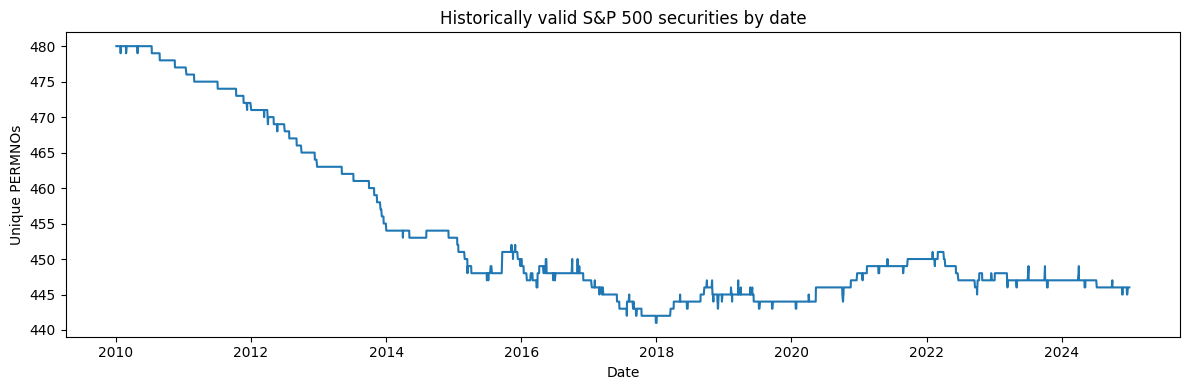

In [33]:
plt.figure(figsize=(12, 4))
plt.plot(
    corrected_stocks_per_day.index,
    corrected_stocks_per_day.values
)

plt.title("Historically valid S&P 500 securities by date")
plt.xlabel("Date")
plt.ylabel("Unique PERMNOs")
plt.tight_layout()
plt.show()

In [34]:
comparison_counts = pd.DataFrame({
    "old_panel": stocks_per_day,
    "corrected_panel": corrected_stocks_per_day
})

comparison_counts["difference"] = (
    comparison_counts["old_panel"]
    - comparison_counts["corrected_panel"]
)

comparison_counts.describe()

,old_panel,corrected_panel,difference
count,3774.000000,3774.000000,3774.000000
mean,592.295178,453.502120,138.793058
std,31.991614,11.236624,25.246253
min,544.000000,441.000000,98.000000
25%,561.000000,446.000000,112.000000
50%,590.000000,448.000000,146.000000
75%,627.000000,460.000000,159.000000
max,634.000000,480.000000,175.000000


In [35]:
unmatched_delistings = db.raw_sql(
    """
    SELECT DISTINCT
        d.permno,
        d.dlstdt,
        d.dlret
    FROM crsp.dsedelist AS d

    INNER JOIN crsp.dsp500list AS s
        ON d.permno = s.permno

    LEFT JOIN crsp.dsf AS a
        ON d.permno = a.permno
       AND d.dlstdt = a.date

    WHERE d.dlstdt BETWEEN '2010-01-01' AND '2024-12-31'
      AND s.ending >= '2010-01-01'
      AND s.start <= '2024-12-31'
      AND d.dlret IS NOT NULL
      AND a.permno IS NULL

    ORDER BY d.dlstdt
    """,
    date_cols=["dlstdt"]
)

print("Unmatched delisting records:", len(unmatched_delistings))
unmatched_delistings.head(20)

Unmatched delisting records: 0


,permno,dlstdt,dlret


In [36]:
unmatched_delistings.to_csv(
    project_root / "reports" / "tables" /
    "unmatched_delisting_returns.csv",
    index=False
)

In [37]:
corrected_path = (
    processed_dir /
    "crsp_sp500_daily_corrected_2010_2024.parquet"
)

corrected_panel.to_parquet(
    corrected_path,
    index=False
)

print("Saved to:", corrected_path)

Saved to: ../data/processed/crsp_sp500_daily_corrected_2010_2024.parquet


In [38]:
reloaded_panel = pd.read_parquet(corrected_path)

print("Reloaded shape:", reloaded_panel.shape)
print("Reloaded columns:", reloaded_panel.columns.tolist())

Reloaded shape: (1711517, 10)
Reloaded columns: ['permno', 'date', 'ticker', 'ret_raw', 'dlret', 'ret', 'mktcap', 'member_start', 'member_end', 'valid_membership']


In [39]:
assert corrected_panel.shape == reloaded_panel.shape

In [40]:
audit_summary = pd.DataFrame({
    "check": [
        "Rows",
        "Unique PERMNOs",
        "Start date",
        "End date",
        "Duplicate PERMNO-date rows",
        "Rows outside membership period",
        "Missing combined returns",
        "Returns below -100%",
        "Negative market caps",
        "Rows containing DLRET",
        "Unmatched delisting records"
    ],
    "result": [
        len(corrected_panel),
        corrected_panel["permno"].nunique(),
        corrected_panel["date"].min(),
        corrected_panel["date"].max(),
        corrected_panel.duplicated(["permno", "date"]).sum(),
        (~corrected_panel["valid_membership"]).sum(),
        corrected_panel["ret"].isna().sum(),
        (corrected_panel["ret"] < -1).sum(),
        (corrected_panel["mktcap"] < 0).sum(),
        corrected_panel["dlret"].notna().sum(),
        len(unmatched_delistings)
    ]
})

audit_summary

,check,result
0,Rows,1711517
1,Unique PERMNOs,740
2,Start date,2010-01-04 00:00:00
3,End date,2024-12-31 00:00:00
4,Duplicate PERMNO-date rows,0
5,Rows outside membership period,0
6,Missing combined returns,60
7,Returns below -100%,0
8,Negative market caps,0
9,Rows containing DLRET,126


In [41]:
audit_summary.to_csv(
    project_root / "reports" / "tables" /
    "crsp_data_audit_summary.csv",
    index=False
)

print("Audit summary saved.")

Audit summary saved.


In [42]:
db.close()
print("WRDS connection closed.")

WRDS connection closed.


In [45]:
if "db" in globals() and db is not None:
    if getattr(db, "connection", None) is not None:
        try:
            db.connection.close()
        except Exception:
            pass

    if getattr(db, "engine", None) is not None:
        try:
            db.engine.dispose()
            db.engine = None
        except Exception:
            pass

    print("WRDS connection is closed or was already closed.")
else:
    print("No WRDS connection exists.")

WRDS connection is closed or was already closed.
